### 학습이 끝난 후 모델별로 점수 작성해놓기(보고서 작성 위함)

In [1]:
import numpy as np
import pandas as pd
import json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import *

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import random
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
import copy

In [2]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size=32):
    """    pandas/numpy 데이터를 PyTorch 학습용 DataLoader와 검증 텐서로 변환합니다."""

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    return train_loader, x_val_tensor, y_val_tensor


def train(dataloader, model, loss_fn, optimizer, device):
    """한 epoch 동안 모델을 학습하고 평균 train loss를 반환합니다."""
    model.train()                               # 훈련 모드로 설정
    total_loss = 0

    for x, y in dataloader:                # (X, y) : 입력 데이터와 레이블
        x, y = x.to(device), y.to(device)  # 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 연결

        # Feed Forward
        optimizer.zero_grad()       # 옵티마이저의 기울기 값 초기화. 기울기가 누적되는 것 방지. 한 배치를 시작할 때 이전 배치의 gradient를 먼저 지우고, 현재 배치의 gradient만 계산
        pred = model(x)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()         # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()        # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트

        total_loss += loss.item() * x.size(0)       # 배치 평균 loss에 배치 크기를 곱해 배치 전체 loss로 누적


    return total_loss / len(dataloader.dataset)     # 전체 데이터 개수로 나누어 epoch 평균 loss 반환



def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    """검증 데이터 전체에 대한 loss와 예측값을 반환합니다."""

    model.eval()         # 모델을 평가 모드로 설정

    with torch.no_grad():       # 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x = x_val_tensor.to(device)
        y = y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item() # 예측 값 pred와 실제 값 y 사이의 손실 계산

    return eval_loss, pred


def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = range(1, len(tr_loss_list) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, tr_loss_list, label="train_loss", marker=".")
    plt.plot(epochs, val_loss_list, label="val_loss", marker=".")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# =================================== MultiTask 용========================================
def make_multitask_dataset(
    x_train,
    x_val,
    y_reg_train,
    y_reg_val,
    y_cls_train,
    y_cls_val,
    batch_size=32
):
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)

    y_reg_train_tensor = torch.tensor(y_reg_train.values, dtype=torch.float32).view(-1, 1)
    y_reg_val_tensor = torch.tensor(y_reg_val.values, dtype=torch.float32).view(-1, 1)

    y_cls_train_tensor = torch.tensor(y_cls_train.values, dtype=torch.long)
    y_cls_val_tensor = torch.tensor(y_cls_val.values, dtype=torch.long)

    train_dataset = TensorDataset(
        x_train_tensor,
        y_reg_train_tensor,
        y_cls_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    return train_loader, x_val_tensor, y_reg_val_tensor, y_cls_val_tensor

def train_multitask(
    dataloader,
    model,
    reg_loss_fn,
    cls_loss_fn,
    optimizer,
    device,
    alpha=1.0,
    beta=0.3
):
    model.train()
    total_loss = 0

    for x, y_reg, y_cls in dataloader:
        x = x.to(device)
        y_reg = y_reg.to(device)
        y_cls = y_cls.to(device)

        optimizer.zero_grad()

        reg_pred, cls_pred = model(x)

        reg_loss = reg_loss_fn(reg_pred, y_reg)
        cls_loss = cls_loss_fn(cls_pred, y_cls)

        loss = alpha * reg_loss + beta * cls_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(dataloader.dataset)

def evaluate_multitask(
    x_val_tensor,
    y_reg_val_tensor,
    y_cls_val_tensor,
    model,
    reg_loss_fn,
    cls_loss_fn,
    device,
    alpha=1.0,
    beta=0.3
):
    model.eval()

    with torch.no_grad():
        x = x_val_tensor.to(device)
        y_reg = y_reg_val_tensor.to(device)
        y_cls = y_cls_val_tensor.to(device)

        reg_pred, cls_pred = model(x)

        reg_loss = reg_loss_fn(reg_pred, y_reg)
        cls_loss = cls_loss_fn(cls_pred, y_cls)

        loss = alpha * reg_loss + beta * cls_loss

    return loss.item(), reg_pred, cls_pred

def evaluate_multitask_metrics(
    model,
    x_val_tensor,
    y_reg_val_tensor,
    y_cls_val_tensor,
    device
):
    model.eval()

    with torch.no_grad():
        reg_pred, cls_pred = model(x_val_tensor.to(device))

    y_reg_pred = reg_pred.cpu().numpy().flatten()
    y_reg_true = y_reg_val_tensor.cpu().numpy().flatten()

    y_cls_pred = torch.argmax(cls_pred, dim=1).cpu().numpy()
    y_cls_true = y_cls_val_tensor.cpu().numpy()

    mse = mean_squared_error(y_reg_true, y_reg_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_reg_true, y_reg_pred)
    r2 = r2_score(y_reg_true, y_reg_pred)

    acc = accuracy_score(y_cls_true, y_cls_pred)

    print("Regression")
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

    print("\nClassification")
    print("Accuracy:", acc)
    print(confusion_matrix(y_cls_true, y_cls_pred))
    print(classification_report(y_cls_true, y_cls_pred))

    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "accuracy": acc,
        "y_reg_true": y_reg_true,
        "y_reg_pred": y_reg_pred,
        "y_cls_true": y_cls_true,
        "y_cls_pred": y_cls_pred,
    }

def parse_json_list(value):
    """JSON 문자열(list[dict])을 파이썬 list로 변환."""
    if pd.isna(value) or value == "":
        return []

    try:
        parsed = json.loads(value)
        return parsed if isinstance(parsed, list) else []
    except json.JSONDecodeError:
        return []


def parse_json_dict(value):
    """JSON 문자열(dict)을 파이썬 dict로 변환."""
    if pd.isna(value) or value == "":
        return {}

    try:
        parsed = json.loads(value)
        return parsed if isinstance(parsed, dict) else {}
    except json.JSONDecodeError:
        return {}
    
class MultiTaskMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(0.25)
        )

        self.reg_head = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 1)
        )

        self.cls_head = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        shared_out = self.shared(x)
        return self.reg_head(shared_out), self.cls_head(shared_out)

### 피처 가공X

In [3]:
data = pd.read_csv('data/processed/feature_table_v2.csv')

In [4]:
data.columns

Index(['movie_id', 'title', 'runtime', 'rating_encoded', 'is_korean', 'genre',
       'open_date', 'open_month', 'open_day_of_week', 'is_summer', 'is_winter',
       'is_holiday_release', 'holiday_nearby_count', 'director_avg_audi',
       'director_movie_count', 'lead_actor_avg_audi', 'lead_actor_movie_count',
       'cast_max_star_power', 'distributor_avg_audi',
       'distributor_movie_count', 'producer_avg_audi', 'producer_movie_count',
       'same_week_releases', 'market_avg_audi_7d', 'total_audience',
       'log_audience', 'hit_class', 'trend_pre7_avg', 'trend_pre7_max',
       'trend_growth_rate', 'relative_search_share', 'is_covid_period',
       'is_peak_season', 'ticket_price_pre30', 'genre_avg_audi',
       'is_new_director', 'is_new_lead', 'is_new_producer',
       'is_new_distributor'],
      dtype='str')

In [5]:
# =====================
# 0. Seed
# =====================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


# =====================
# 1. Load
# =====================
data = pd.read_csv("data/processed/feature_table_v2.csv")

data["open_date"] = pd.to_datetime(data["open_date"], errors="coerce")
data["open_year"] = data["open_date"].dt.year

before_rows = len(data)

# 2016년 이후만 사용
data = data[data["open_year"] >= 2016].copy()

after_rows = len(data)
removed_rows = before_rows - after_rows

print(f"필터 전 행 수: {before_rows:,}")
print(f"필터 후 행 수: {after_rows:,}")
print(f"제거된 행 수: {removed_rows:,}")
print(f"유지 비율: {after_rows / before_rows:.2%}")

# =====================
# 2. Feature / Target
# =====================
target_col = "log_audience"

exclude_cols = [
    "movie_id",
    "title",
    'open_date',
    "open_year",
    "total_audience",
    "log_audience",
    "hit_class",
]

feature_cols = [c for c in data.columns if c not in exclude_cols]

X = data[feature_cols].copy()
y = data[target_col].copy()

# =====================
# 3. Preprocessing
# =====================

impute_cols = [
    "director_avg_audi",
    "lead_actor_avg_audi",
    "distributor_avg_audi",
    "producer_avg_audi",
]

for col in impute_cols:
    if col in X.columns:
        if col == "lead_actor_avg_audi":
            new_col = "is_new_lead"
        else:
            new_col = f"is_new_{col.replace('_avg_audi', '')}"

        X[new_col] = (X[col] == 0).astype(int)

        non_zero_median = X.loc[X[col] > 0, col].median()
        if pd.isna(non_zero_median):
            non_zero_median = 0

        X.loc[X[col] == 0, col] = non_zero_median

log_cols = [
    "director_avg_audi",
    "lead_actor_avg_audi",
    "distributor_avg_audi",
    "producer_avg_audi",
    "market_avg_audi_7d",
]

for col in log_cols:
    if col in X.columns:
        X[col] = np.log1p(X[col])

one_hot_cols = [
    "rating_encoded",
    "genre",
    "open_month",
    "open_day_of_week",
]

one_hot_cols = [c for c in one_hot_cols if c in X.columns]

X = pd.get_dummies(
    X,
    columns=one_hot_cols,
    drop_first=True,
    dtype=int,
)

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

print(f"최종 feature 수: {X.shape[1]}")
print(f"최종 데이터 행 수: {X.shape[0]}")

# =====================
# 4. Train / Valid / Test Split
# =====================
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=SEED,
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=SEED,
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_valid_tensor = torch.tensor(X_valid_scaled, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=64,
    shuffle=True,
)

valid_loader = DataLoader(
    TensorDataset(X_valid_tensor, y_valid_tensor),
    batch_size=128,
    shuffle=False,
)

# =====================
# 5. MLP Regressor
# =====================
class MLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)


model = MLPRegressor(input_dim=X_train_scaled.shape[1]).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=10,
)

# =====================
# 6. Train
# =====================
EPOCHS = 300
PATIENCE = 30

best_valid_loss = float("inf")
best_state = None
patience_count = 0

history = {
    "train_loss": [],
    "valid_loss": [],
}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    model.eval()
    valid_losses = []

    with torch.no_grad():
        for xb, yb in valid_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)
            loss = criterion(pred, yb)

            valid_losses.append(loss.item())

    train_loss = np.mean(train_losses)
    valid_loss = np.mean(valid_losses)

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)

    scheduler.step(valid_loss)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_state = model.state_dict()
        patience_count = 0
    else:
        patience_count += 1

    if epoch % 20 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Valid Loss: {valid_loss:.4f}"
        )

    if patience_count >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break
# =====================
# 7. Evaluation
# =====================
model.eval()

with torch.no_grad():
    test_pred = model(X_test_tensor.to(device)).cpu().numpy().reshape(-1)

y_true = y_test.values

rmse = mean_squared_error(y_true, test_pred) ** 0.5
mae = mean_absolute_error(y_true, test_pred)
r2 = r2_score(y_true, test_pred)

print("[MLP Regression - log_audience]")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")


필터 전 행 수: 2,454
필터 후 행 수: 2,454
제거된 행 수: 0
유지 비율: 100.00%
최종 feature 수: 68
최종 데이터 행 수: 2454
Epoch 020 | Train Loss: 3.4150 | Valid Loss: 3.5336
Epoch 040 | Train Loss: 2.8600 | Valid Loss: 3.1715
Epoch 060 | Train Loss: 2.5699 | Valid Loss: 2.8071
Epoch 080 | Train Loss: 2.5904 | Valid Loss: 2.7954
Epoch 100 | Train Loss: 2.5242 | Valid Loss: 2.7356
Early stopping at epoch 118
[MLP Regression - log_audience]
RMSE: 1.6124
MAE : 1.2971
R2  : 0.4781


### 피처 가공 OO

In [6]:
feature_cols_from_data= [
    "is_peak_season",
    "is_holiday_release",
    "holiday_nearby_count",
    "rating_encoded",
    "open_day_of_week",
    "distributor_avg_audi",
    "distributor_movie_count",
    "producer_avg_audi",
    "producer_movie_count",
    "director_avg_audi",
    "director_movie_count",
    "lead_actor_avg_audi",
    "lead_actor_movie_count",
    "is_korean",
    "same_week_releases",
    "runtime",
    "trend_pre7_avg",
    "trend_pre7_max",
    "trend_growth_rate",
    "relative_search_share",
    "market_avg_audi_7d",
    "ticket_price_pre30",
    "genre",
    "open_date",
    "is_covid_period",
    "open_month",
    "log_audience",
    'hit_class'
]

data_df = data[feature_cols_from_data].copy()
REMAP = {0: 0, 1: 1, 2: 1, 3: 1}  # 100만 미만=0, 이상=1
data_df['hit_class'] = data_df['hit_class'].map(REMAP).astype('Int64')

data_df.columns

Index(['is_peak_season', 'is_holiday_release', 'holiday_nearby_count',
       'rating_encoded', 'open_day_of_week', 'distributor_avg_audi',
       'distributor_movie_count', 'producer_avg_audi', 'producer_movie_count',
       'director_avg_audi', 'director_movie_count', 'lead_actor_avg_audi',
       'lead_actor_movie_count', 'is_korean', 'same_week_releases', 'runtime',
       'trend_pre7_avg', 'trend_pre7_max', 'trend_growth_rate',
       'relative_search_share', 'market_avg_audi_7d', 'ticket_price_pre30',
       'genre', 'open_date', 'is_covid_period', 'open_month', 'log_audience',
       'hit_class'],
      dtype='str')

In [7]:
import random
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ===========================
# Seed / Device
# ===========================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ===========================
# Feature / Target
# ===========================

target_col = "log_audience"

drop_cols = [
    "open_date",
    "log_audience",
    "hit_class",
]

data = data_df.copy()

X = data.drop(columns=[c for c in drop_cols if c in data.columns]).copy()
y = data[target_col].astype(float).copy()


# ===========================
# Log Transform
# ===========================

log_cols = [
    "distributor_avg_audi",
    "producer_avg_audi",
    "director_avg_audi",
    "lead_actor_avg_audi",
    "market_avg_audi_7d",
    "ticket_price_pre30",
]

log_cols = [c for c in log_cols if c in X.columns]

X[log_cols] = X[log_cols].clip(lower=0)
X[log_cols] = np.log1p(X[log_cols])


# ===========================
# Feature Groups
# ===========================

categorical_features = [
    "rating_encoded",
    "genre",
    "open_month",
    "open_day_of_week",
]

binary_features = [
    "is_peak_season",
    "is_holiday_release",
    "is_korean",
    "is_covid_period",
]

categorical_features = [c for c in categorical_features if c in X.columns]
binary_features = [c for c in binary_features if c in X.columns]

scale_features = [
    c for c in X.columns
    if c not in categorical_features + binary_features
]


# ===========================
# Preprocessor
# ===========================

try:
    onehot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    onehot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )


numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", onehot_encoder),
    ]
)

binary_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("scale", numeric_pipeline, scale_features),
        ("onehot", categorical_pipeline, categorical_features),
        ("binary", binary_pipeline, binary_features),
    ],
    remainder="drop"
)


# ===========================
# Train / Validation Split
# ===========================
# 데이터가 부족하므로 split은 한 번만 진행
# train 80%, val 20%

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
)


# ===========================
# Fit Preprocessor Only on Train
# ===========================

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)


# ===========================
# TensorDataset / DataLoader
# ===========================

X_train_tensor = torch.tensor(
    np.asarray(X_train_processed),
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.to_numpy(dtype=np.float32),
    dtype=torch.float32
).reshape(-1, 1)

X_val_tensor = torch.tensor(
    np.asarray(X_val_processed),
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val.to_numpy(dtype=np.float32),
    dtype=torch.float32
).reshape(-1, 1)


train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=128,
    shuffle=False
)


# ===========================
# Model
# ===========================

class AudienceRegressionMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.05),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


input_dim = X_train_processed.shape[1]

model = AudienceRegressionMLP(input_dim).to(device)

loss_fn = nn.MSELoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


# ===========================
# Train / Evaluate Functions
# ===========================

def train_regression(dataloader, model, loss_fn, optimizer, device):
    model.train()
    total_loss = 0

    for xb, yb in dataloader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        pred = model(xb)
        loss = loss_fn(pred, yb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    return total_loss / len(dataloader.dataset)


def evaluate_regression(dataloader, model, loss_fn, device):
    model.eval()

    total_loss = 0
    preds = []
    trues = []

    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)
            loss = loss_fn(pred, yb)

            total_loss += loss.item() * xb.size(0)

            preds.append(pred.cpu().numpy())
            trues.append(yb.cpu().numpy())

    avg_loss = total_loss / len(dataloader.dataset)

    preds = np.vstack(preds).reshape(-1)
    trues = np.vstack(trues).reshape(-1)

    return avg_loss, preds, trues


# ===========================
# Training
# ===========================

EPOCHS = 300
PATIENCE = 20

best_val_loss = np.inf
best_model_state = None
wait = 0

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_regression(
        train_loader,
        model,
        loss_fn,
        optimizer,
        device
    )

    val_loss, val_pred, val_true = evaluate_regression(
        val_loader,
        model,
        loss_fn,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

    if wait >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break


# ===========================
# Load Best Model
# ===========================

model.load_state_dict(best_model_state)


# ===========================
# Final Evaluation - Validation
# ===========================

final_val_loss, y_val_pred_log, y_val_true_log = evaluate_regression(
    val_loader,
    model,
    loss_fn,
    device
)

rmse_log = mean_squared_error(y_val_true_log, y_val_pred_log) ** 0.5
mae_log = mean_absolute_error(y_val_true_log, y_val_pred_log)
r2_log = r2_score(y_val_true_log, y_val_pred_log)


# ===========================
# Original Scale Metrics
# ===========================

y_val_true_audience = np.expm1(y_val_true_log)
y_val_pred_audience = np.expm1(y_val_pred_log)

rmse_audience = mean_squared_error(
    y_val_true_audience,
    y_val_pred_audience
) ** 0.5

mae_audience = mean_absolute_error(
    y_val_true_audience,
    y_val_pred_audience
)

r2_audience = r2_score(
    y_val_true_audience,
    y_val_pred_audience
)


# ===========================
# Print Results
# ===========================

print("\n[MLP Regression - log_audience]")

print(f"Best Val Loss : {best_val_loss:.4f}")
print(f"Final Val Loss: {final_val_loss:.4f}")

print("\nLog Scale Metrics")
print(f"RMSE Log: {rmse_log:.4f}")
print(f"MAE Log : {mae_log:.4f}")
print(f"R2 Log  : {r2_log:.4f}")

print("\nOriginal Audience Scale Metrics")
print(f"RMSE Audience: {rmse_audience:.2f}")
print(f"MAE Audience : {mae_audience:.2f}")
print(f"R2 Audience  : {r2_audience:.4f}")

Epoch 001 | Train Loss: 86.0173 | Val Loss: 34.1740
Epoch 010 | Train Loss: 2.6102 | Val Loss: 1.9132
Epoch 020 | Train Loss: 2.2201 | Val Loss: 1.8418
Epoch 030 | Train Loss: 1.9433 | Val Loss: 1.7940
Epoch 040 | Train Loss: 1.8434 | Val Loss: 1.8651
Epoch 050 | Train Loss: 1.7298 | Val Loss: 1.8385
Early stopping at epoch 52

[MLP Regression - log_audience]
Best Val Loss : 1.7783
Final Val Loss: 1.7783

Log Scale Metrics
RMSE Log: 1.3335
MAE Log : 1.0418
R2 Log  : 0.6416

Original Audience Scale Metrics
RMSE Audience: 1087558.93
MAE Audience : 385721.22
R2 Audience  : 0.3835


In [8]:
# ===================== 분류: train/val 0.8:0.2 =========================


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

target_cols = ["log_audience", "hit_class"]
target_col = "hit_class"

data_df = data_df.copy()

X = data_df.drop(columns=target_cols, errors="ignore").copy()
y = data_df[target_col].copy().astype(float)

X = X.drop(columns=["open_date"], errors="ignore")


# =====================
# Log Transform
# =====================

log_cols = [
    "distributor_avg_audi",
    "producer_avg_audi",
    "director_avg_audi",
    "lead_actor_avg_audi",
    "market_avg_audi_7d",
    "ticket_price_pre30",
]

log_cols = [c for c in log_cols if c in X.columns]

X[log_cols] = X[log_cols].clip(lower=0)
X[log_cols] = np.log1p(X[log_cols])


# =====================
# One-Hot Encoding
# =====================

one_hot_cols = [
    "rating_encoded",
    "genre",
    "open_month",
    "open_day_of_week",
]

one_hot_cols = [c for c in one_hot_cols if c in X.columns]

X = pd.get_dummies(
    X,
    columns=one_hot_cols,
    drop_first=True,
    dtype=int,
)


# =====================
# Missing / Infinite 처리
# =====================

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))


# =====================
# Train / Validation Split
# =====================
# 데이터 부족하므로 한 번만 split
# train 80%, val 20%

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)


# =====================
# Scaling
# =====================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


# =====================
# Tensor 변환
# =====================

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)


# =====================
# DataLoader
# =====================

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=64,
    shuffle=True,
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=128,
    shuffle=False,
)


# =====================
# Model
# =====================

class MLPClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)


model = MLPClassifier(input_dim=X_train_scaled.shape[1]).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)


# =====================
# Training
# =====================

EPOCHS = 300
PATIENCE = 30

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None
patience_count = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    batch_train_losses = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        batch_train_losses.append(loss.item())

    train_loss = np.mean(batch_train_losses)

    model.eval()
    batch_val_losses = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            batch_val_losses.append(loss.item())

    val_loss = np.mean(batch_val_losses)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        patience_count = 0
    else:
        patience_count += 1

    if epoch % 20 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

    if patience_count >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break


# =====================
# Best Model Load
# =====================

model.load_state_dict(best_model_state)


# =====================
# Validation Evaluation
# =====================

model.eval()

with torch.no_grad():
    val_logits = model(X_val_tensor.to(device)).cpu()
    val_prob = torch.sigmoid(val_logits).numpy().reshape(-1)

y_true = y_val.values.astype(int)
y_pred = (val_prob >= 0.5).astype(int)


# =====================
# Metrics
# =====================

acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
auc = roc_auc_score(y_true, val_prob)
cm = confusion_matrix(y_true, y_pred)


print("[MLP Classification - hit_class]")
print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Val Loss  : {val_losses[-1]:.4f}")
print(f"Best Val Loss   : {best_val_loss:.4f}")

print("\nValidation Metrics")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

Epoch 001 | Train Loss: 0.5570 | Val Loss: 0.4312
Epoch 020 | Train Loss: 0.0922 | Val Loss: 0.2491
Early stopping at epoch 36
[MLP Classification - hit_class]
Final Train Loss: 0.0528
Final Val Loss  : 0.2961
Best Val Loss   : 0.2072

Validation Metrics
Accuracy : 0.8859
Precision: 0.5821
Recall   : 0.5821
F1 Score : 0.5821
ROC-AUC  : 0.9388

Confusion Matrix:
[[396  28]
 [ 28  39]]


### 피처 가공 O


In [9]:
df = pd.read_csv('data/processed/feature_table_v2.csv')

df['hit_class'].value_counts()

hit_class
0    2121
1     210
2      62
3      61
Name: count, dtype: int64

In [10]:
################### 상관관계 파악

# 타겟 컬럼
target_cols = ["total_audience", "log_audience"]

# 제외할 컬럼
exclude_cols = [
    "movie_id",
    "title",
    "genre",
    "open_date",
    "hit_class",
    "total_audience",
    "log_audience",
]

# 숫자형 피처만 선택
feature_cols = [
    col for col in df.select_dtypes(include="number").columns
    if col not in exclude_cols
]

# Pearson 상관관계
corr_result = df[feature_cols + target_cols].corr(method="pearson")[target_cols]

# 타겟과의 상관관계만 추출
corr_result = corr_result.loc[feature_cols]

# 절댓값 기준 정렬용 컬럼 추가
corr_result["max_abs_corr"] = corr_result[target_cols].abs().max(axis=1)

# 상관관계 높은 순서로 정렬
corr_result = corr_result.sort_values("max_abs_corr", ascending=False)

corr_result


,total_audience,log_audience,max_abs_corr
trend_pre7_avg,0.541036,0.470247,0.541036
relative_search_share,0.488690,0.425951,0.488690
distributor_avg_audi,0.249665,0.481734,0.481734
cast_max_star_power,0.332840,0.400497,0.400497
trend_pre7_max,0.380764,0.350843,0.380764
runtime,0.263938,0.294427,0.294427
lead_actor_avg_audi,0.237151,0.292984,0.292984
market_avg_audi_7d,0.131153,0.284050,0.284050
is_covid_period,-0.137931,-0.281319,0.281319
genre_avg_audi,0.200463,0.265529,0.265529


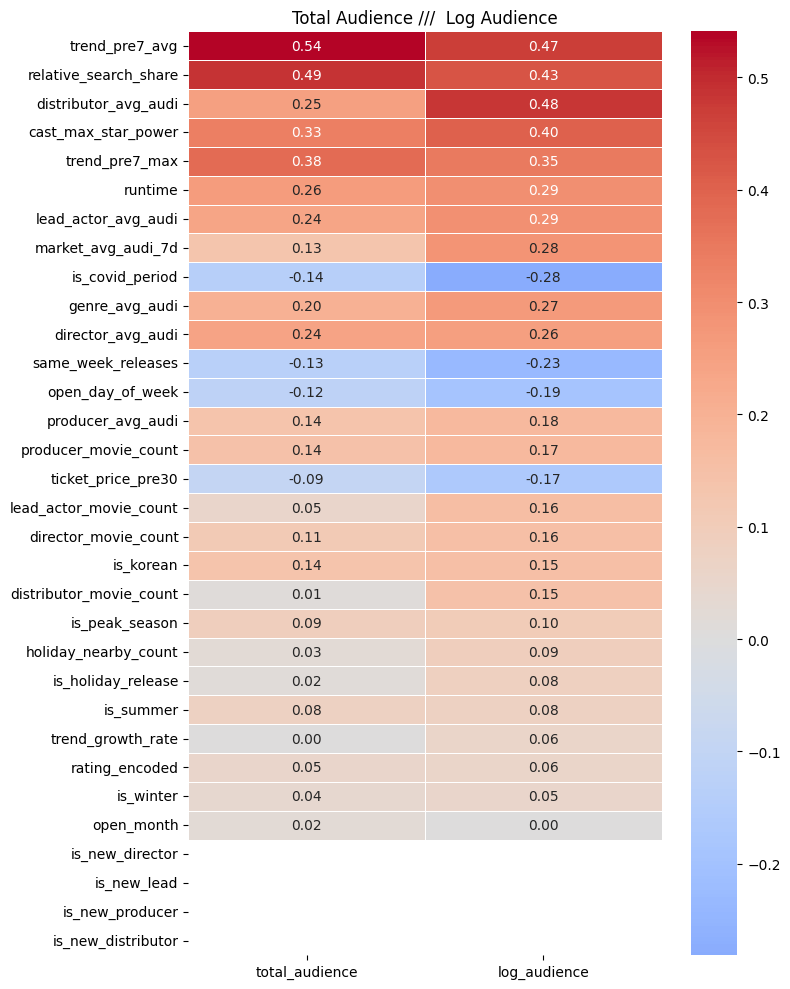

In [11]:

plt.figure(figsize=(8, 10))

sns.heatmap(
    corr_result[target_cols],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
)

plt.title("Total Audience ///  Log Audience")
plt.tight_layout()
plt.show()

In [12]:
dff = df.copy()

In [13]:
dff["is_peak"] = dff["open_month"].isin([12, 1, 7, 8]).astype(int)

dff = dff.drop(columns=["is_summer", "is_winter", "open_month"])

peak_col = ['is_peak']

In [14]:
# ==============================is_peak===================================

In [15]:
holiday_cols = ['is_holiday_release', 'holiday_nearby_count']

In [16]:
# =====================holiday drop or no 해보기===================

In [17]:
dff['rating_encoded'].value_counts()
rating_col = ['rating_encoded']

In [18]:
# ==================rating encoded ==============================

In [19]:
dff['open_day_of_week']

0       3.0
1       3.0
2       2.0
3       4.0
4       2.0
       ... 
2449    4.0
2450    4.0
2451    3.0
2452    4.0
2453    4.0
Name: open_day_of_week, Length: 2454, dtype: float64

In [20]:
def map_three_days(day):
    if day == 2:
        return "wed"
    elif day == 3:
        return "thur"
    else:
        return "others"

dff["three_days"] = dff["open_day_of_week"].apply(map_three_days)

# dff.drop(columns='open_day_of_week')
dff['three_days']

0         thur
1         thur
2          wed
3       others
4          wed
         ...  
2449    others
2450    others
2451      thur
2452    others
2453    others
Name: three_days, Length: 2454, dtype: str

In [21]:
day_col = ['three_days']

In [22]:
# =======================수/목/다른 요일 그룹화========================

In [23]:
distributor_cols = ['distributor_avg_audi', 'distributor_movie_count']

In [24]:
dff[distributor_cols].corr()

,distributor_avg_audi,distributor_movie_count
distributor_avg_audi,1.000000,0.392998
distributor_movie_count,0.392998,1.000000


In [25]:
# ==================배급사 cols=========================

In [26]:
producer_cols=['producer_avg_audi', 'producer_movie_count']

In [27]:
dff[producer_cols].corr()

,producer_avg_audi,producer_movie_count
producer_avg_audi,1.000000,0.005325
producer_movie_count,0.005325,1.000000


In [28]:
# ==================제작사 cols==========================

In [29]:
director_cols = ['director_avg_audi', 'director_movie_count']

In [30]:
# ==================감독 cols=======================

In [31]:
actor_cast_cols = ['lead_actor_avg_audi', 'lead_actor_movie_count']

In [32]:
dff[actor_cast_cols+['log_audience']].corr()

,lead_actor_avg_audi,lead_actor_movie_count,log_audience
lead_actor_avg_audi,1.000000,0.179233,0.292984
lead_actor_movie_count,0.179233,1.000000,0.157607
log_audience,0.292984,0.157607,1.000000


In [33]:
# ==================actor, cast col===================================

In [34]:
lang_col = ['is_korean']

In [35]:
# ================== is_korean==================

In [36]:
release_col = ['same_week_releases']

In [37]:
# =============== release===================

In [38]:
def categorize_runtime(runtime):
    if runtime < 90:
        return "short"
    elif runtime < 120:
        return "normal"
    elif runtime < 130:
        return "long"
    else:
        return "x_long"

dff["runtime_category"] = dff["runtime"].apply(categorize_runtime)
dff['runtime_category'].value_counts()

runtime_category
normal    1402
short      489
x_long     293
long       270
Name: count, dtype: int64

In [39]:
runtime_category = ['runtime_category']

In [40]:
# =============runtime group==================

In [41]:
trend_cols = ['trend_pre7_avg', 'trend_pre7_max', 'trend_growth_rate', 'market_avg_audi_7d', 'relative_search_share']

In [42]:
df[trend_cols+['total_audience','log_audience']].corr()

,trend_pre7_avg,trend_pre7_max,trend_growth_rate,market_avg_audi_7d,relative_search_share,total_audience,log_audience
trend_pre7_avg,1.000000,0.908465,0.051802,0.176097,0.608423,0.541036,0.470247
trend_pre7_max,0.908465,1.000000,0.090268,0.170501,0.434621,0.380764,0.350843
trend_growth_rate,0.051802,0.090268,1.000000,-0.025650,-0.026179,0.003804,0.056716
market_avg_audi_7d,0.176097,0.170501,-0.025650,1.000000,-0.037335,0.131153,0.284050
relative_search_share,0.608423,0.434621,-0.026179,-0.037335,1.000000,0.488690,0.425951
total_audience,0.541036,0.380764,0.003804,0.131153,0.488690,1.000000,0.625802
log_audience,0.470247,0.350843,0.056716,0.284050,0.425951,0.625802,1.000000


In [43]:
df[trend_cols].corr()

,trend_pre7_avg,trend_pre7_max,trend_growth_rate,market_avg_audi_7d,relative_search_share
trend_pre7_avg,1.000000,0.908465,0.051802,0.176097,0.608423
trend_pre7_max,0.908465,1.000000,0.090268,0.170501,0.434621
trend_growth_rate,0.051802,0.090268,1.000000,-0.025650,-0.026179
market_avg_audi_7d,0.176097,0.170501,-0.025650,1.000000,-0.037335
relative_search_share,0.608423,0.434621,-0.026179,-0.037335,1.000000


In [44]:
final_trend_cols = ['trend_pre7_avg','trend_growth_rate', 'relative_search_share',
 'market_avg_audi_7d']

In [45]:
# =================트렌드 정리=======================

# 학습 후 컬럼 분석 공간

In [46]:
X.columns

Index(['is_peak_season', 'is_holiday_release', 'holiday_nearby_count',
       'distributor_avg_audi', 'distributor_movie_count', 'producer_avg_audi',
       'producer_movie_count', 'director_avg_audi', 'director_movie_count',
       'lead_actor_avg_audi', 'lead_actor_movie_count', 'is_korean',
       'same_week_releases', 'runtime', 'trend_pre7_avg', 'trend_pre7_max',
       'trend_growth_rate', 'relative_search_share', 'market_avg_audi_7d',
       'ticket_price_pre30', 'is_covid_period', 'rating_encoded_1.0',
       'rating_encoded_2.0', 'rating_encoded_3.0', 'genre_가족', 'genre_공연',
       'genre_공포(호러)', 'genre_기타', 'genre_다큐멘터리', 'genre_드라마', 'genre_멜로/로맨스',
       'genre_뮤지컬', 'genre_미스터리', 'genre_범죄', 'genre_사극', 'genre_성인물(에로)',
       'genre_스릴러', 'genre_애니메이션', 'genre_액션', 'genre_어드벤처', 'genre_전쟁',
       'genre_코미디', 'genre_판타지', 'open_month_2.0', 'open_month_3.0',
       'open_month_4.0', 'open_month_5.0', 'open_month_6.0', 'open_month_7.0',
       'open_month_8.0', 'open_mon

# 즐거운 학습 타임

In [47]:
final_cols = peak_col+holiday_cols+rating_col+day_col+distributor_cols+producer_cols+director_cols+actor_cast_cols+lang_col+release_col+runtime_category+final_trend_cols
final_cols = final_cols+['log_audience', 'total_audience', 'runtime']

In [48]:
realfinalcol = final_cols + ['total_audience', 'log_audience', 'hit_class', 'ticket_price_pre30']
realfinalcol
tdf = dff[realfinalcol]

In [49]:
realfinalcol = list(dict.fromkeys(realfinalcol))
realfinalcol
tdf = dff[realfinalcol].copy()

In [50]:
log_transform_cols = [
    "director_avg_audi",
    "lead_actor_avg_audi",
    "distributor_avg_audi",
    "producer_avg_audi",
    "market_avg_audi_7d",
    "trend_pre7_avg",
    "relative_search_share",
    "director_movie_count",
    "lead_actor_movie_count",
    "distributor_movie_count",
    "producer_movie_count",
    'ticket_price_pre30'
]

tdf_log = tdf.copy()

for col in log_transform_cols:
    tdf_log[col] = np.log1p(tdf_log[col])

In [51]:
dff["open_date"] = pd.to_datetime(dff["open_date"], errors="coerce")
dff["open_year"] = dff["open_date"].dt.year

In [52]:
dff["is_covid"] = dff["open_year"].between(2020, 2022).astype(int)
dff['is_covid']

0       0
1       1
2       1
3       0
4       1
       ..
2449    0
2450    0
2451    0
2452    0
2453    0
Name: is_covid, Length: 2454, dtype: int64

In [53]:
# ### 빠진 cols
# 
#     "genre",
#     "open_year",
#     "is_covid",
#     "has_producer_history",
#     "has_distributor_history",
#     "has_lead_actor_history",
#     "has_director_history",
#     "has_nearby_holiday",
#     "trend_pre7_max",
# 

tdf_log[['genre',"open_year", 'is_covid']] = dff[['genre',"open_year", 'is_covid', ]]

In [54]:
REMAP = {0: 0, 1: 1, 2: 1, 3: 1}  # 100만 미만=0, 이상=1
tdf_log['hit_class'] = tdf_log['hit_class'].map(REMAP).astype('Int64')

In [55]:
tdf_log.columns

Index(['is_peak', 'is_holiday_release', 'holiday_nearby_count',
       'rating_encoded', 'three_days', 'distributor_avg_audi',
       'distributor_movie_count', 'producer_avg_audi', 'producer_movie_count',
       'director_avg_audi', 'director_movie_count', 'lead_actor_avg_audi',
       'lead_actor_movie_count', 'is_korean', 'same_week_releases',
       'runtime_category', 'trend_pre7_avg', 'trend_growth_rate',
       'relative_search_share', 'market_avg_audi_7d', 'log_audience',
       'total_audience', 'runtime', 'hit_class', 'ticket_price_pre30', 'genre',
       'open_year', 'is_covid'],
      dtype='str')

In [56]:
# =========================== Deep Learning Regression with tdf_log ===========================

# =========================== Feature / Target ===========================

target_col = "log_audience"

drop_cols = [
    "movie_id",
    "title",
    "open_date",
    "total_audience",
    "log_audience",
    "hit_class"
]

feature_cols = [
    col for col in tdf_log.columns
    if col not in drop_cols
]

X = tdf_log[feature_cols].copy()
y = tdf_log[target_col].astype(float).copy()


# =========================== Preprocessing ===========================

onehot_features = [
    "is_peak",
    "is_holiday_release",
    "rating_encoded",
    "three_days",
    "is_korean",
    "runtime_category",
    'genre'
    
]

scale_features = [
    col for col in X.columns
    if col not in onehot_features
]

preprocessor = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), scale_features),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), onehot_features),
    ],
    remainder="drop"
)


# =========================== Train / Validation Split ===========================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)


# =========================== TensorDataset / DataLoader ===========================

x_train_tensor = torch.tensor(np.asarray(X_train_processed), dtype=torch.float32)
y_train_tensor = torch.tensor(
    y_train.to_numpy(dtype=np.float32),
    dtype=torch.float32
).reshape(-1, 1)

x_val_tensor = torch.tensor(np.asarray(X_val_processed), dtype=torch.float32)
y_val_tensor = torch.tensor(
    y_val.to_numpy(dtype=np.float32),
    dtype=torch.float32
).reshape(-1, 1)

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)


# =========================== Model ===========================

class AudienceRegressionMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.05),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


# =========================== Train / Evaluate Functions ===========================

def train_regression(dataloader, model, loss_fn, optimizer, device):
    model.train()
    total_loss = 0

    for x, y_batch in dataloader:
        x = x.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        pred = model(x)
        loss = loss_fn(pred, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(dataloader.dataset)


def evaluate_regression(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()

    with torch.no_grad():
        x = x_val_tensor.to(device)
        y_batch = y_val_tensor.to(device)

        pred = model(x)
        loss = loss_fn(pred, y_batch).item()

    return loss, pred


# =========================== Training ===========================

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_processed.shape[1]

model_reg = AudienceRegressionMLP(input_dim).to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=1e-4)

epochs = 200
patience = 10
best_val_loss = np.inf
best_model_state = None
wait = 0

tr_loss_list = []
val_loss_list = []

for epoch in range(1, epochs + 1):
    train_loss = train_regression(
        train_loader,
        model_reg,
        loss_fn,
        optimizer,
        device
    )

    val_loss, val_pred = evaluate_regression(
        x_val_tensor,
        y_val_tensor,
        model_reg,
        loss_fn,
        device
    )

    tr_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model_reg.state_dict()
        wait = 0
    else:
        wait += 1

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"train_loss: {train_loss:.4f} | "
            f"val_loss: {val_loss:.4f}"
        )

    if wait >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

model_reg.load_state_dict(best_model_state)


# =========================== Final Evaluation ===========================

final_val_loss, final_val_pred = evaluate_regression(
    x_val_tensor,
    y_val_tensor,
    model_reg,
    loss_fn,
    device
)

y_val_true_log = y_val_tensor.cpu().numpy().reshape(-1)
y_val_pred_log = final_val_pred.cpu().numpy().reshape(-1)

rmse_log = np.sqrt(mean_squared_error(y_val_true_log, y_val_pred_log))
mae_log = mean_absolute_error(y_val_true_log, y_val_pred_log)
r2_log = r2_score(y_val_true_log, y_val_pred_log)

y_val_true_audience = np.expm1(y_val_true_log)
y_val_pred_audience = np.expm1(y_val_pred_log)

rmse_audience = np.sqrt(mean_squared_error(y_val_true_audience, y_val_pred_audience))
mae_audience = mean_absolute_error(y_val_true_audience, y_val_pred_audience)
r2_audience = r2_score(y_val_true_audience, y_val_pred_audience)

print("Validation Regression Metrics")
print("Log RMSE:", rmse_log)
print("Log MAE :", mae_log)
print("Log R2  :", r2_log)

print("\nOriginal Scale Metrics")
print("RMSE:", rmse_audience)
print("MAE :", mae_audience)
print("R2  :", r2_audience)

Epoch 001 | train_loss: 74.2384 | val_loss: 17.7665
Epoch 010 | train_loss: 2.6019 | val_loss: 1.7760
Epoch 020 | train_loss: 2.2145 | val_loss: 1.8276
Early stopping at epoch 29
Validation Regression Metrics
Log RMSE: 1.3559907902824002
Log MAE : 1.0520124435424805
Log R2  : 0.629376232624054

Original Scale Metrics
RMSE: 1108839.9378665977
MAE : 372716.96875
R2  : 0.3591878414154053


In [57]:
# =========================== Deep Learning Classification with tdf_log ===========================

# =========================== Feature / Target ===========================

target_col = "hit_class"

drop_cols = [
    "movie_id",
    "title",
    "open_date",
    "total_audience",
    "log_audience",
    "hit_class"
]

feature_cols = [
    col for col in tdf_log.columns
    if col not in drop_cols
]

X = tdf_log[feature_cols].copy()
y = tdf_log[target_col].copy()


# =========================== Preprocessing ===========================

onehot_features = [
    "is_peak",
    "is_holiday_release",
    "rating_encoded",
    "three_days",
    "is_korean",
    "runtime_category",
    "genre"
]

scale_features = [
    col for col in X.columns
    if col not in onehot_features
]

preprocessor = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), scale_features),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), onehot_features),
    ],
    remainder="drop"
)


# =========================== Class Label Encoding ===========================

class_names = sorted(y.dropna().unique())
class_to_idx = {label: idx for idx, label in enumerate(class_names)}
idx_to_class = {idx: label for label, idx in class_to_idx.items()}

y_encoded = y.map(class_to_idx).astype(int)

num_classes = len(class_names)

print("class_to_idx:", class_to_idx)
print("num_classes:", num_classes)


# =========================== Train / Validation Split ===========================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)


# =========================== TensorDataset / DataLoader ===========================

x_train_tensor = torch.tensor(np.asarray(X_train_processed), dtype=torch.float32)
y_train_tensor = torch.tensor(
    y_train.to_numpy(dtype=np.int64),
    dtype=torch.long
)

x_val_tensor = torch.tensor(np.asarray(X_val_processed), dtype=torch.float32)
y_val_tensor = torch.tensor(
    y_val.to_numpy(dtype=np.int64),
    dtype=torch.long
)

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)


# =========================== Model ===========================

class AudienceClassificationMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.05),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)


# =========================== Train / Evaluate Functions ===========================

def train_classification(dataloader, model, loss_fn, optimizer, device):
    model.train()
    total_loss = 0

    for x, y_batch in dataloader:
        x = x.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        pred = model(x)
        loss = loss_fn(pred, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(dataloader.dataset)


def evaluate_classification(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()

    with torch.no_grad():
        x = x_val_tensor.to(device)
        y_batch = y_val_tensor.to(device)

        pred = model(x)
        loss = loss_fn(pred, y_batch).item()

    return loss, pred


# =========================== Training ===========================

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_processed.shape[1]

model_cls = AudienceClassificationMLP(input_dim, num_classes).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cls.parameters(), lr=0.001, weight_decay=1e-4)

epochs = 200
patience = 10
best_val_loss = np.inf
best_model_state = None
wait = 0

tr_loss_list = []
val_loss_list = []

for epoch in range(1, epochs + 1):
    train_loss = train_classification(
        train_loader,
        model_cls,
        loss_fn,
        optimizer,
        device
    )

    val_loss, val_pred = evaluate_classification(
        x_val_tensor,
        y_val_tensor,
        model_cls,
        loss_fn,
        device
    )

    tr_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model_cls.state_dict()
        wait = 0
    else:
        wait += 1

    if epoch % 10 == 0 or epoch == 1:
        y_val_pred_tmp = torch.argmax(val_pred, dim=1).cpu().numpy()
        val_acc = accuracy_score(y_val, y_val_pred_tmp)

        print(
            f"Epoch {epoch:03d} | "
            f"train_loss: {train_loss:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"val_acc: {val_acc:.4f}"
        )

    if wait >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

model_cls.load_state_dict(best_model_state)


# =========================== Final Evaluation ===========================

final_val_loss, final_val_pred = evaluate_classification(
    x_val_tensor,
    y_val_tensor,
    model_cls,
    loss_fn,
    device
)

y_val_true = y_val_tensor.cpu().numpy()
y_val_pred = torch.argmax(final_val_pred, dim=1).cpu().numpy()

acc = accuracy_score(y_val_true, y_val_pred)
precision = precision_score(y_val_true, y_val_pred, average="weighted", zero_division=0)
recall = recall_score(y_val_true, y_val_pred, average="weighted", zero_division=0)
f1 = f1_score(y_val_true, y_val_pred, average="weighted", zero_division=0)

print("Validation Classification Metrics")
print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nConfusion Matrix")
print(confusion_matrix(y_val_true, y_val_pred))

print("\nClassification Report")
print(
    classification_report(
        y_val_true,
        y_val_pred,
        target_names=[str(idx_to_class[i]) for i in range(num_classes)],
        zero_division=0
    )
)

class_to_idx: {np.int64(0): 0, np.int64(1): 1}
num_classes: 2
Epoch 001 | train_loss: 0.3188 | val_loss: 0.2201 | val_acc: 0.8941
Epoch 010 | train_loss: 0.1329 | val_loss: 0.2288 | val_acc: 0.9043
Early stopping at epoch 16
Validation Classification Metrics
Accuracy : 0.8981670061099797
Precision: 0.8969116174933564
Recall   : 0.8981670061099797
F1-score : 0.8975153475572788

Confusion Matrix
[[400  24]
 [ 26  41]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       424
           1       0.63      0.61      0.62        67

    accuracy                           0.90       491
   macro avg       0.78      0.78      0.78       491
weighted avg       0.90      0.90      0.90       491



In [58]:
tdf_log['hit_class'].value_counts()

hit_class
0    2121
1     333
Name: count, dtype: Int64

In [59]:
# ============================가중치 추가 분류===================================
#  =========================== Deep Learning Classification with Class Weights ===========================


# ===========================
# Seed / Device
# ===========================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ===========================
# Feature / Target
# ===========================

target_col = "hit_class"

drop_cols = [
    "movie_id",
    "title",
    "open_date",
    "total_audience",
    "log_audience",
    "hit_class"
]

feature_cols = [
    col for col in tdf_log.columns
    if col not in drop_cols
]

X = tdf_log[feature_cols].copy()
y = tdf_log[target_col].copy()


# ===========================
# Preprocessing
# ===========================

onehot_features = [
    "is_peak",
    "is_holiday_release",
    "rating_encoded",
    "three_days",
    "is_korean",
    "runtime_category",
    "genre"
]

onehot_features = [c for c in onehot_features if c in X.columns]

scale_features = [
    col for col in X.columns
    if col not in onehot_features
]

try:
    onehot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    onehot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

preprocessor = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), scale_features),
        ("onehot", onehot_encoder, onehot_features),
    ],
    remainder="drop"
)


# ===========================
# Class Label Encoding
# ===========================

class_names = sorted(y.dropna().unique())

class_to_idx = {
    label: idx
    for idx, label in enumerate(class_names)
}

idx_to_class = {
    idx: label
    for label, idx in class_to_idx.items()
}

y_encoded = y.map(class_to_idx).astype(int)

num_classes = len(class_names)




# ===========================
# Train / Validation Split
# ===========================
# 데이터 부족하므로 0.8 : 0.2 한 번만 split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)


# ===========================
# Class Weight 계산
# ===========================
# weight = 전체 train 샘플 수 / (클래스 수 * 해당 클래스 샘플 수)

class_counts = y_train.value_counts().sort_index()
class_counts = class_counts.reindex(range(num_classes), fill_value=0)

class_weights = len(y_train) / (num_classes * class_counts)
class_weights = class_weights.replace([np.inf, -np.inf], 0)

class_weights_tensor = torch.tensor(
    class_weights.values,
    dtype=torch.float32
).to(device)



# ===========================
# TensorDataset / DataLoader
# ===========================

x_train_tensor = torch.tensor(
    np.asarray(X_train_processed),
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.to_numpy(dtype=np.int64),
    dtype=torch.long
)

x_val_tensor = torch.tensor(
    np.asarray(X_val_processed),
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val.to_numpy(dtype=np.int64),
    dtype=torch.long
)

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)


# ===========================
# Model
# ===========================

class AudienceClassificationMLPWeighted(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.05),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)


# ===========================
# Train / Evaluate Functions
# ===========================

def train_classification(dataloader, model, loss_fn, optimizer, device):
    model.train()
    total_loss = 0

    for x_batch, y_batch in dataloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(x_batch)
        loss = loss_fn(logits, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)

    return total_loss / len(dataloader.dataset)


def evaluate_classification(x_tensor, y_tensor, model, loss_fn, device):
    model.eval()

    with torch.no_grad():
        x_tensor = x_tensor.to(device)
        y_tensor = y_tensor.to(device)

        logits = model(x_tensor)
        loss = loss_fn(logits, y_tensor).item()

    return loss, logits


# ===========================
# Training
# ===========================

input_dim = X_train_processed.shape[1]

model_cls_weighted = AudienceClassificationMLPWeighted(
    input_dim=input_dim,
    num_classes=num_classes
).to(device)

# 핵심: 클래스 가중치 적용
loss_fn = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

optimizer = optim.Adam(
    model_cls_weighted.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

epochs = 200
patience = 10

best_val_loss = np.inf
best_model_state = None
wait = 0

tr_loss_list_weighted = []
val_loss_list_weighted = []

for epoch in range(1, epochs + 1):
    train_loss = train_classification(
        train_loader,
        model_cls_weighted,
        loss_fn,
        optimizer,
        device
    )

    val_loss, val_logits = evaluate_classification(
        x_val_tensor,
        y_val_tensor,
        model_cls_weighted,
        loss_fn,
        device
    )

    tr_loss_list_weighted.append(train_loss)
    val_loss_list_weighted.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model_cls_weighted.state_dict())
        wait = 0
    else:
        wait += 1

    if epoch % 10 == 0 or epoch == 1:
        y_val_pred_tmp = torch.argmax(val_logits, dim=1).cpu().numpy()
        val_acc = accuracy_score(y_val, y_val_pred_tmp)

        print(
            f"train_loss: {train_loss:.4f} | ",
            f"val_loss: {val_loss:.4f} | "
         
        )

    if wait >= patience:
        print(f"Early stopping at epoch {epoch}")
        break


# ===========================
# Load Best Model
# ===========================

model_cls_weighted.load_state_dict(best_model_state)


# ===========================
# Final Evaluation
# ===========================

final_val_loss, final_val_logits = evaluate_classification(
    x_val_tensor,
    y_val_tensor,
    model_cls_weighted,
    loss_fn,
    device
)

y_val_true = y_val_tensor.cpu().numpy()
y_val_pred = torch.argmax(final_val_logits, dim=1).cpu().numpy()

acc = accuracy_score(y_val_true, y_val_pred)

precision_weighted = precision_score(
    y_val_true,
    y_val_pred,
    average="weighted",
    zero_division=0
)

recall_weighted = recall_score(
    y_val_true,
    y_val_pred,
    average="weighted",
    zero_division=0
)

f1_weighted = f1_score(
    y_val_true,
    y_val_pred,
    average="weighted",
    zero_division=0
)

precision_macro = precision_score(
    y_val_true,
    y_val_pred,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    y_val_true,
    y_val_pred,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    y_val_true,
    y_val_pred,
    average="macro",
    zero_division=0
)


# ===========================
# Results
# ===========================

print("\nValidation Metrics")
print(f"Accuracy          : {acc:.4f}")
print(f"Precision weighted: {precision_weighted:.4f}")
print(f"Recall weighted   : {recall_weighted:.4f}")
print(f"F1 weighted       : {f1_weighted:.4f}")
print(f"Precision macro   : {precision_macro:.4f}")
print(f"Recall macro      : {recall_macro:.4f}")
print(f"F1 macro          : {f1_macro:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_val_true, y_val_pred))


print("\nClassification Report")
print(
    classification_report(
        y_val_true,
        y_val_pred,
        target_names=[str(idx_to_class[i]) for i in range(num_classes)],
        zero_division=0
    )
)


train_loss: 0.4586 |  val_loss: 0.3347 | 
train_loss: 0.1839 |  val_loss: 0.4106 | 
Early stopping at epoch 12

Validation Metrics
Accuracy          : 0.8615
Precision weighted: 0.9149
Recall weighted   : 0.8615
F1 weighted       : 0.8767
Precision macro   : 0.7385
Recall macro      : 0.8758
F1 macro          : 0.7763

Confusion Matrix
[[363  61]
 [  7  60]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.86      0.91       424
           1       0.50      0.90      0.64        67

    accuracy                           0.86       491
   macro avg       0.74      0.88      0.78       491
weighted avg       0.91      0.86      0.88       491



In [60]:
tdf['ticket_price_pre30']

0        7993.272093
1        9859.892076
2       10234.188266
3        9532.658866
4        9587.370927
            ...     
2449     9947.507635
2450     9947.507635
2451     9977.339066
2452     9856.584674
2453     9856.584674
Name: ticket_price_pre30, Length: 2454, dtype: float64

### 피처: history 등

In [61]:
new_df = tdf_log.copy()

In [62]:
ndfcols = new_df.columns

In [63]:
count_cols = [col for col in ndfcols if "count" in col]
count_cols.remove('holiday_nearby_count')
count_cols

['distributor_movie_count',
 'producer_movie_count',
 'director_movie_count',
 'lead_actor_movie_count']

In [64]:
new_df = new_df.drop(columns=count_cols)

In [65]:
# ========================== 감독/제작사/배급사/배우 작품 수 drop 후 학습

# =========================== Feature / Target ===========================

target_col = "log_audience"

drop_cols = [
    "movie_id",
    "title",
    "open_date",
    "total_audience",
    "log_audience",
    "hit_class"
]

feature_cols = [
    col for col in new_df.columns
    if col not in drop_cols
]

X = new_df[feature_cols].copy()
y = new_df[target_col].astype(float).copy()


# =========================== Preprocessing ===========================

onehot_features = [
    "is_peak",
    "is_holiday_release",
    "rating_encoded",
    "three_days",
    "is_korean",
    "runtime_category",
    'genre'
    
]

scale_features = [
    col for col in X.columns
    if col not in onehot_features
]

preprocessor = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), scale_features),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), onehot_features),
    ],
    remainder="drop"
)


# =========================== Train / Validation Split ===========================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)


# =========================== TensorDataset / DataLoader ===========================

x_train_tensor = torch.tensor(np.asarray(X_train_processed), dtype=torch.float32)
y_train_tensor = torch.tensor(
    y_train.to_numpy(dtype=np.float32),
    dtype=torch.float32
).reshape(-1, 1)

x_val_tensor = torch.tensor(np.asarray(X_val_processed), dtype=torch.float32)
y_val_tensor = torch.tensor(
    y_val.to_numpy(dtype=np.float32),
    dtype=torch.float32
).reshape(-1, 1)

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)


# =========================== Model ===========================

class AudienceRegressionMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.05),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


# =========================== Train / Evaluate Functions ===========================

def train_regression(dataloader, model, loss_fn, optimizer, device):
    model.train()
    total_loss = 0

    for x, y_batch in dataloader:
        x = x.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        pred = model(x)
        loss = loss_fn(pred, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(dataloader.dataset)


def evaluate_regression(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()

    with torch.no_grad():
        x = x_val_tensor.to(device)
        y_batch = y_val_tensor.to(device)

        pred = model(x)
        loss = loss_fn(pred, y_batch).item()

    return loss, pred


# =========================== Training ===========================

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_processed.shape[1]

model_reg = AudienceRegressionMLP(input_dim).to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=1e-4)

epochs = 200
patience = 10
best_val_loss = np.inf
best_model_state = None
wait = 0

tr_loss_list = []
val_loss_list = []

for epoch in range(1, epochs + 1):
    train_loss = train_regression(
        train_loader,
        model_reg,
        loss_fn,
        optimizer,
        device
    )

    val_loss, val_pred = evaluate_regression(
        x_val_tensor,
        y_val_tensor,
        model_reg,
        loss_fn,
        device
    )

    tr_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model_reg.state_dict()
        wait = 0
    else:
        wait += 1

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"train_loss: {train_loss:.4f} | "
            f"val_loss: {val_loss:.4f}"
        )

    if wait >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

model_reg.load_state_dict(best_model_state)


# =========================== Final Evaluation ===========================

final_val_loss, final_val_pred = evaluate_regression(
    x_val_tensor,
    y_val_tensor,
    model_reg,
    loss_fn,
    device
)

y_val_true_log = y_val_tensor.cpu().numpy().reshape(-1)
y_val_pred_log = final_val_pred.cpu().numpy().reshape(-1)

rmse_log = np.sqrt(mean_squared_error(y_val_true_log, y_val_pred_log))
mae_log = mean_absolute_error(y_val_true_log, y_val_pred_log)
r2_log = r2_score(y_val_true_log, y_val_pred_log)

y_val_true_audience = np.expm1(y_val_true_log)
y_val_pred_audience = np.expm1(y_val_pred_log)

rmse_audience = np.sqrt(mean_squared_error(y_val_true_audience, y_val_pred_audience))
mae_audience = mean_absolute_error(y_val_true_audience, y_val_pred_audience)
r2_audience = r2_score(y_val_true_audience, y_val_pred_audience)

print("Validation Regression Metrics")
print("Log RMSE:", rmse_log)
print("Log MAE :", mae_log)
print("Log R2  :", r2_log)

print("\nOriginal Scale Metrics")
print("RMSE:", rmse_audience)
print("MAE :", mae_audience)
print("R2  :", r2_audience)

Epoch 001 | train_loss: 77.3100 | val_loss: 23.0288
Epoch 010 | train_loss: 2.7263 | val_loss: 1.7351
Epoch 020 | train_loss: 2.4295 | val_loss: 1.8331
Early stopping at epoch 20
Validation Regression Metrics
Log RMSE: 1.3539064842087443
Log MAE : 1.0439953804016113
Log R2  : 0.6305147409439087

Original Scale Metrics
RMSE: 1111868.7416057708
MAE : 383163.78125
R2  : 0.3556821942329407


# ########################################## #

# ########################################## #

In [74]:
df =pd.read_csv('data/processed/feature_table_v2.csv')

In [75]:
df.columns

Index(['movie_id', 'title', 'runtime', 'rating_encoded', 'is_korean', 'genre',
       'open_date', 'open_month', 'open_day_of_week', 'is_summer', 'is_winter',
       'is_holiday_release', 'holiday_nearby_count', 'director_avg_audi',
       'director_movie_count', 'lead_actor_avg_audi', 'lead_actor_movie_count',
       'cast_max_star_power', 'distributor_avg_audi',
       'distributor_movie_count', 'producer_avg_audi', 'producer_movie_count',
       'same_week_releases', 'market_avg_audi_7d', 'total_audience',
       'log_audience', 'hit_class', 'trend_pre7_avg', 'trend_pre7_max',
       'trend_growth_rate', 'relative_search_share', 'is_covid_period',
       'is_peak_season', 'ticket_price_pre30', 'genre_avg_audi',
       'is_new_director', 'is_new_lead', 'is_new_producer',
       'is_new_distributor'],
      dtype='str')

In [68]:
df['genre_avg_audi']

0       12.861455
1       12.984166
2       12.683620
3       12.657033
4       13.044063
          ...    
2449    12.672881
2450    12.672881
2451    10.588402
2452    12.669571
2453    12.669571
Name: genre_avg_audi, Length: 2454, dtype: float64

In [ ]:
df = df.drop(columns=['movie_id',
    'title',
    'open_date',
    'trend_pre7_max',
    'open_month', 'is_summer', 'is_winter', 'trend_pre7_avg', ])

In [70]:
df.columns.to_list()


['runtime',
 'rating_encoded',
 'is_korean',
 'genre',
 'open_day_of_week',
 'is_holiday_release',
 'holiday_nearby_count',
 'director_avg_audi',
 'director_movie_count',
 'lead_actor_avg_audi',
 'lead_actor_movie_count',
 'distributor_avg_audi',
 'distributor_movie_count',
 'producer_avg_audi',
 'producer_movie_count',
 'same_week_releases',
 'market_avg_audi_7d',
 'total_audience',
 'log_audience',
 'hit_class',
 'trend_pre7_avg',
 'trend_growth_rate',
 'relative_search_share',
 'is_covid_period',
 'is_peak_season',
 'ticket_price_pre30',
 'genre_avg_audi',
 'is_new_director',
 'is_new_lead',
 'is_new_producer',
 'is_new_distributor']

In [71]:
len(df.columns)

31

In [72]:
no_encode_scale_cols = [ 'distributor_avg_audi',  'producer_avg_audi',
                  'lead_actor_avg_audi', 'director_avg_audi','is_peak_season',
                  'is_holiday_release','genre_avg_audi', 'is_korean', 'is_covid_period',
                  'is_new_director', 'is_new_lead', 'is_new_producer',
                    'is_new_distributor', 'market_avg_audi_7d']
t_cols = ['hit_class', 'total_audience', 'log_audience']
len(no_encode_scale_cols)

14

In [82]:
left_cols = [i for i in df.columns.to_list() if i not in no_encode_scale_cols]
df[['trend_pre7_max', 'trend_pre7_avg']].max()

trend_pre7_max    100.000000
trend_pre7_avg     31.938571
dtype: float64

In [88]:
df[['log_audience','cast_max_star_power','lead_actor_avg_audi','trend_pre7_max']].corr(numeric_only=True)

,log_audience,cast_max_star_power,lead_actor_avg_audi,trend_pre7_max
log_audience,1.000000,0.400497,0.292984,0.350843
cast_max_star_power,0.400497,1.000000,0.625919,0.228680
lead_actor_avg_audi,0.292984,0.625919,1.000000,0.147578
trend_pre7_max,0.350843,0.228680,0.147578,1.000000


In [89]:
df[['log_audience', 'trend_pre7_avg', 'trend_pre7_max',
       'trend_growth_rate', 'relative_search_share']].corr(numeric_only=True)

,log_audience,trend_pre7_avg,trend_pre7_max,trend_growth_rate,relative_search_share
log_audience,1.000000,0.470247,0.350843,0.056716,0.425951
trend_pre7_avg,0.470247,1.000000,0.908465,0.051802,0.608423
trend_pre7_max,0.350843,0.908465,1.000000,0.090268,0.434621
trend_growth_rate,0.056716,0.051802,0.090268,1.000000,-0.026179
relative_search_share,0.425951,0.608423,0.434621,-0.026179,1.000000


In [92]:
o = [ 'runtime', 'rating_encoded', 'is_korean', 'genre', 'genre_avg_audi',
       'open_day_of_week']
t = [ 'is_holiday_release', 'holiday_nearby_count']
th = ['director_avg_audi',
       'director_movie_count', 'lead_actor_avg_audi', 'lead_actor_movie_count',
       'cast_max_star_power', 'distributor_avg_audi',
       'distributor_movie_count', 'producer_avg_audi', 'producer_movie_count']
f = [ 'same_week_releases']
fi = [ 'market_avg_audi_7d','trend_pre7_max',
       'trend_growth_rate', 'relative_search_share']
s = ['is_covid_period',
       'is_peak_season', 'ticket_price_pre30']
se = ['is_new_director', 'is_new_lead', 'is_new_producer',
       'is_new_distributor']

In [99]:
df[['log_audience']+se].corr(numeric_only=True)

,log_audience,is_new_director,is_new_lead,is_new_producer,is_new_distributor
log_audience,1.0,NaN,NaN,NaN,NaN
is_new_director,NaN,NaN,NaN,NaN,NaN
is_new_lead,NaN,NaN,NaN,NaN,NaN
is_new_producer,NaN,NaN,NaN,NaN,NaN
is_new_distributor,NaN,NaN,NaN,NaN,NaN


In [101]:
df['is_new_lead'].value_counts()

is_new_lead
0    2454
Name: count, dtype: int64